# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Contexte** 

* La ville de Seattle souhaite atteindre la neutralité carbone d'ici 2050.
* Les relevés énergétiques des bâtiments sont coûteux à réaliser et ne sont pas disponibles pour l'ensemble du parc immobilier.
* L'objectif est d'utiliser les données collectées en 2016 afin d'estimer la consommation énergétique des bâtiments non destinés à l’habitation.

## **Objectif** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **Objectfs Data** 
- **Comprendre le jeu de données :** analyser la structure, les types de variables, les valeurs manquantes et la qualité des données.
- **Nettoyer et préparer les données :** sélectionner les bâtiments non résidentiels, traiter les incohérences et préparer les variables pour la modélisation.
- **Réaliser une analyse exploratoire (EDA) :** identifier les distributions, les corrélations et les facteurs susceptibles d'influencer la consommation énergétique.
- **Construire et comparer plusieurs modèles de régression** afin de prédire la consommation énergétique des bâtiments.
- **Interpréter le modèle retenu :** analyser l'importance des variables explicatives et identifier les principaux facteurs influençant la consommation énergétique.

## **ÉTAPE 1** 

### **Réalisez une analyse exploratoire**

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse :

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

#### **Importation des librairies**

In [ ]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


#### **Importation du Dataset**

In [ ]:
df_building_consumption = pd.read_csv("../data/2016_Building_Energy_Benchmarking.csv")

#### **Analyse Exploratoire des données**

##### **Standardisation des colonnes**

> * Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques.

In [ ]:
# visualisation des colonnes de la base de données
df_building_consumption.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [ ]:
#Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques

df_building_consumption.columns = (
    df_building_consumption.columns
    .str.lower()                  # minúscules
    .str.strip()                  # remotion des espaces en début et fin de chaîne
    .str.replace(" ", "_")        # espace -> _
    .str.replace("-", "_")        # hífen -> _

)

In [ ]:
# visualisation des colonnes après adaptation et standardisation

df_building_consumption.columns

Index(['osebuildingid', 'datayear', 'buildingtype', 'primarypropertytype',
       'propertyname', 'address', 'city', 'state', 'zipcode',
       'taxparcelidentificationnumber', 'councildistrictcode', 'neighborhood',
       'latitude', 'longitude', 'yearbuilt', 'numberofbuildings',
       'numberoffloors', 'propertygfatotal', 'propertygfaparking',
       'propertygfabuilding(s)', 'listofallpropertyusetypes',
       'largestpropertyusetype', 'largestpropertyusetypegfa',
       'secondlargestpropertyusetype', 'secondlargestpropertyusetypegfa',
       'thirdlargestpropertyusetype', 'thirdlargestpropertyusetypegfa',
       'yearsenergystarcertified', 'energystarscore', 'siteeui(kbtu/sf)',
       'siteeuiwn(kbtu/sf)', 'sourceeui(kbtu/sf)', 'sourceeuiwn(kbtu/sf)',
       'siteenergyuse(kbtu)', 'siteenergyusewn(kbtu)', 'steamuse(kbtu)',
       'electricity(kwh)', 'electricity(kbtu)', 'naturalgas(therms)',
       'naturalgas(kbtu)', 'defaultdata', 'comments', 'compliancestatus',
       'outlier

##### **Dimensions**

In [ ]:
print("La base de données contient", df_building_consumption.shape[0], "lignes et", df_building_consumption.shape[1], "colonnes.")

La base de données contient 3376 lignes et 46 colonnes.


In [ ]:
# On regarde comment un batiment est défini dans ce jeu de données 

df_building_consumption.head()

,osebuildingid,datayear,buildingtype,primarypropertytype,propertyname,address,city,state,zipcode,taxparcelidentificationnumber,...,electricity(kwh),electricity(kbtu),naturalgas(therms),naturalgas(kbtu),defaultdata,comments,compliancestatus,outlier,totalghgemissions,ghgemissionsintensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
# Aperçu derniéres 5 lignes

df_building_consumption.tail()

,osebuildingid,datayear,buildingtype,primarypropertytype,propertyname,address,city,state,zipcode,taxparcelidentificationnumber,...,electricity(kwh),electricity(kbtu),naturalgas(therms),naturalgas(kbtu),defaultdata,comments,compliancestatus,outlier,totalghgemissions,ghgemissionsintensity
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,...,153655.0000,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,116221.0000,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,525251.6875,1.792159e+06,39737.390630,3.973739e+06,False,NaN,Compliant,NaN,223.54,16.99
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,102248.0000,3.488702e+05,3706.010010,3.706010e+05,False,NaN,Compliant,NaN,22.11,1.57
3375,50226,2016,Nonresidential COS,Mixed Use Property,Van Asselt Community Center,2820 S Myrtle St,Seattle,WA,NaN,7857002030,...,126774.3984,4.325542e+05,7203.419922,7.203420e+05,False,NaN,Compliant,NaN,41.27,2.26


> * Les cinq premiers et 5 derniéres enregistrements correspondent à des hôtels situés à Seattle (WA) en 2016. 
> * Ils illustrent les principales variables du jeu de données : localisation, caractéristiques du bâtiment, consommation énergétique et émissions de gaz à effet de serre.


##### **Doublons**

In [ ]:
# Verification des doublons dans le jeu de données

df_building_consumption.duplicated().sum()

np.int64(0)

> **Observation :** 

> * Aucun doublon n'a été identifié dans le jeu de données (`0` doublon). Chaque enregistrement correspond donc à un bâtiment unique, ce qui garantit que les analyses statistiques et la future modélisation ne seront pas biaisées par des observations dupliquées.

##### **Statistiques descriptives**

In [ ]:
describe = df_building_consumption.describe().T

describe.style.format(
    lambda x: f"{x:,.2f}".replace(",", " ").replace(".", ",")
)

,count,mean,std,min,25%,50%,75%,max
osebuildingid,"3 376,00","21 208,99","12 223,76","1,00","19 990,75","23 112,00","25 994,25","50 226,00"
datayear,"3 376,00","2 016,00","0,00","2 016,00","2 016,00","2 016,00","2 016,00","2 016,00"
zipcode,"3 360,00","98 116,95","18,62","98 006,00","98 105,00","98 115,00","98 122,00","98 272,00"
councildistrictcode,"3 376,00","4,44","2,12","1,00","3,00","4,00","7,00","7,00"
latitude,"3 376,00","47,62","0,05","47,50","47,60","47,62","47,66","47,73"
longitude,"3 376,00","-122,33","0,03","-122,41","-122,35","-122,33","-122,32","-122,22"
yearbuilt,"3 376,00","1 968,57","33,09","1 900,00","1 948,00","1 975,00","1 997,00","2 015,00"
numberofbuildings,"3 368,00","1,11","2,11","0,00","1,00","1,00","1,00","111,00"
numberoffloors,"3 376,00","4,71","5,49","0,00","2,00","4,00","5,00","99,00"
propertygfatotal,"3 376,00","94 833,54","218 837,61","11 285,00","28 487,00","44 175,00","90 992,00","9 320 156,00"


> **Observation :** 
> * Les statistiques descriptives montrent que le jeu de données contient 3 376 bâtiments. Les variables `datayear`, `city` et `state` sont concernent une seule campagne de collecte réalisée en 2016 à Seattle. 
> * Les caractéristiques physiques des bâtiments présentent une forte variabilité, notamment la surface totale (`propertygfatotal`) et le nombre d'étages (`numberoffloors`). 
> * Les variables de consommation énergétique et d'émissions de gaz à effet de serre suggérent la présence de valeurs extrêmes qui devront être analysées.   

     

In [ ]:
df_building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   osebuildingid                    3376 non-null   int64  
 1   datayear                         3376 non-null   int64  
 2   buildingtype                     3376 non-null   str    
 3   primarypropertytype              3376 non-null   str    
 4   propertyname                     3376 non-null   str    
 5   address                          3376 non-null   str    
 6   city                             3376 non-null   str    
 7   state                            3376 non-null   str    
 8   zipcode                          3360 non-null   float64
 9   taxparcelidentificationnumber    3376 non-null   str    
 10  councildistrictcode              3376 non-null   int64  
 11  neighborhood                     3376 non-null   str    
 12  latitude                       

> **Observation :** 
>  * Le jeu de données contient **3 376 observations** et **46 variables**. 
>  * L'aperçu fourni par `info()` met en évidence la présence de valeurs manquantes dans certaines variables, notamment `zipcode`, `numberofbuildings`, `totalghgemissions` et `ghgemissionsintensity`. 
>  * Les types de données sont cohérents avec la nature des variables et ne nécessitent pas de conversion particulière à ce stade.

     

##### **Valeurs manquantes**

In [ ]:
# identification des valeurs manquantes

for col in df_building_consumption.columns:
    print(f"\n--- {col} ---")
    print(df_building_consumption[col].value_counts(dropna=False).head())


--- osebuildingid ---
osebuildingid
1    1
2    1
3    1
5    1
8    1
Name: count, dtype: int64

--- datayear ---
datayear
2016    3376
Name: count, dtype: int64

--- buildingtype ---
buildingtype
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Name: count, dtype: int64

--- primarypropertytype ---
primarypropertytype
Low-Rise Multifamily           987
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    293
Other                          256
Warehouse                      187
Name: count, dtype: int64

--- propertyname ---
propertyname
Northgate Plaza            3
Lakeview                   2
South Park                 2
Garden Court Apartments    2
Central Park               2
Name: count, dtype: int64

--- address ---
address
2600 SW Barton St              4
2203 Airport Way S             4
309 South Cloverdale Street    4
500 5TH AVE                    2
3613 4th Ave S   

In [ ]:
# Calcul du pourcentage moyen de valeurs manquantes par colonne

df_building_consumption["comments"].value_counts(dropna=False)

comments
NaN    3376
Name: count, dtype: int64

In [ ]:
#creation d'un tableau récapitulatif des colonnes de la base de données

summary = pd.DataFrame({
    "dtype": df_building_consumption.dtypes,
    "non_null": df_building_consumption.count(),
    "missing": df_building_consumption.isna().sum(),
    "missing_pct": (
        df_building_consumption.isna().mean() * 100
    ).round(2),
    "n_unique": df_building_consumption.nunique()
})

summary.sort_values("missing_pct", ascending=False)

,dtype,non_null,missing,missing_pct,n_unique
comments,float64,0,3376,100.00,0
outlier,str,32,3344,99.05,2
yearsenergystarcertified,object,119,3257,96.48,65
thirdlargestpropertyusetype,str,596,2780,82.35,44
thirdlargestpropertyusetypegfa,float64,596,2780,82.35,501
secondlargestpropertyusetype,str,1679,1697,50.27,50
secondlargestpropertyusetypegfa,float64,1679,1697,50.27,1352
energystarscore,float64,2533,843,24.97,100
largestpropertyusetypegfa,float64,3356,20,0.59,3122
largestpropertyusetype,str,3356,20,0.59,56


> **Observation :** 

> * Les colonnes `comments` (100 %), `outlier` (99,05 %) et `yearenergystarcertified` (96,48 %) sont presque entièrement vides et seront étudiées afin de déterminer leur intérêt pour la modélisation. 
> * La colonne `comments`  est entièrement vide et ne fournit aucune information exploitable pour expliquer la consommation énergétique ou les émissions de gaz à effet de serre. Elle pourra donc être supprimée.
> * Les variables `secondlargestpropertyusetype` et `thirdlargestpropertyusetype`, ainsi que leurs surfaces associées, présentent également un nombre élevé de valeurs manquantes. En revanche, la majorité des autres variables comporte moins de 1 % de valeurs manquantes.
>          

##### **Variables constantes**

In [ ]:
# Identification des colonnes constantes

constant_columns = ["city", "state", "datayear"]

for col in constant_columns:
    print(f"\n--- {col} ---")
    print(df_building_consumption[col].value_counts(dropna=False))


--- city ---
city
Seattle    3376
Name: count, dtype: int64

--- state ---
state
WA    3376
Name: count, dtype: int64

--- datayear ---
datayear
2016    3376
Name: count, dtype: int64


> - L'analyse des fréquences confirme que les variables `city`, `state` et `datayear` sont constantes dans l'ensemble du jeu de données. 
> - Tous les bâtiments sont situés à Seattle (WA) et les observations concernent exclusivement l'année 2016. 
> - Comme l'étude porte exclusivement sur des bâtiments non résidentiels situés à Seattle en 2016 ces variables n'apportent donc aucun pouvoir discriminant et pourront être supprimées lors de la préparation des données pour la modélisation.


##### **Comparaison des bâtiments mono et multi-usages**

In [ ]:
# Création d'une nouvelle colonne "usage_type" pour identifier les bâtiments à usage unique et les bâtiments à usages multiples

df_building_consumption["usage_type"] = np.where(
    df_building_consumption["secondlargestpropertyusetype"].isna(),
    "Mono-usage",
    "Multi-usages"
)

##### **Répartition**

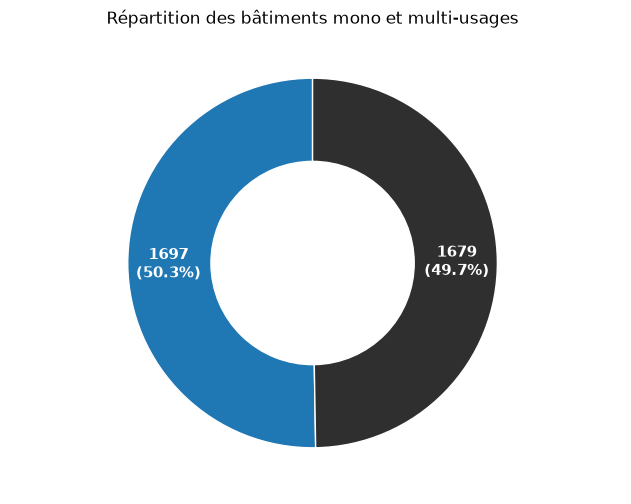

In [ ]:
# Visualisation de la répartition des bâtiments mono et multi-usages

usage_counts = df_building_consumption["usage_type"].value_counts()

def autopct_format(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100))
        return f"{count}\n({pct:.1f}%)"
    return inner

plt.figure(figsize=(6, 6))

plt.pie(
    usage_counts,
    labels=usage_counts.index,
    colors=["#1f77b4", "#2f2f2f"],
    startangle=90,
    autopct=autopct_format(usage_counts),
    pctdistance=0.78,              # <- aproxima os números do centro
    labeldistance=1.08,            # <- mantém os rótulos um pouco para fora
    wedgeprops=dict(width=0.45, edgecolor="white"),
    textprops=dict(color="white", fontsize=11, fontweight="bold")
)

plt.title("Répartition des bâtiments mono et multi-usages")

plt.show()

> - La répartition des bâtiments est pratiquement équilibrée entre les catégories **mono-usage** et **multi-usages**, ce qui permet une comparaison pertinente.

##### **Consommation énergétique selon le type d'usage**

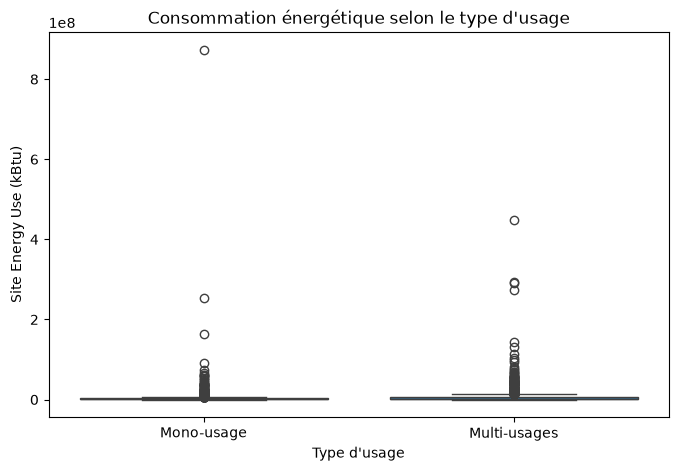

In [ ]:
# Visualisation de la consommation énergétique selon le type d'usage

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_building_consumption,
    x="usage_type",
    y="siteenergyuse(kbtu)"
)

plt.title("Consommation énergétique selon le type d'usage")
plt.xlabel("Type d'usage")
plt.ylabel("Site Energy Use (kBtu)")

plt.show()

> - Le boxplot met en évidence la présence de nombreuses valeurs aberrantes dans les deux catégories. 
> - Ces bâtiments présentent une consommation énergétique exceptionnellement élevée, ce qui écrase la distribution et rend difficile la comparaison des valeurs centrales entre les bâtiments mono-usage et multi-usages.


##### **Tableau comparatif des bâtiments mono et multi-usages**

In [ ]:
# Tableau comparatif des bâtiments mono et multi-usages (médianes)

comparison_table = (
    df_building_consumption
    .groupby("usage_type")[
        [
            "propertygfatotal",
            "numberoffloors",
            "siteenergyuse(kbtu)",
            "totalghgemissions",
            "energystarscore"
        ]
    ]
    .median()
    .T
)

comparison_table.columns = ["Mono-usage", "Multi-usages"]

comparison_table.index = [
    "Property GFA Total",
    "Number of Floors",
    "Site Energy Use (kBtu)",
    "Total GHG Emissions",
    "Energy Star Score"
]

# Ajout de la colonne d'interprétation
comparison_table["Interprétation"] = [
    "Les bâtiments multi-usages présentent une surface médiane plus importante.",
    "Les bâtiments multi-usages comptent davantage d'étages.",
    "Les bâtiments multi-usages consomment davantage d'énergie.",
    "Les bâtiments multi-usages émettent davantage de GES.",
    "Les bâtiments multi-usages présentent un Energy Star Score médian plus élevé."
]

# Transformation de l'index en colonne
comparison_table = (
    comparison_table
    .reset_index()
    .rename(columns={"index": "Variable"})
)

# Affichage
comparison_table.style\
    .format({
        "Mono-usage": "{:,.0f}",
        "Multi-usages": "{:,.0f}"
    })\
    .set_properties(
        subset=["Variable", "Mono-usage", "Multi-usages"],
        **{"text-align": "center"}
    )\
    .set_properties(
        subset=["Interprétation"],
        **{"text-align": "left"}
    )\
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        }
    ])

,Variable,Mono-usage,Multi-usages,Interprétation
0,Property GFA Total,"38,255","56,259",Les bâtiments multi-usages présentent une surface médiane plus importante.
1,Number of Floors,3,4,Les bâtiments multi-usages comptent davantage d'étages.
2,Site Energy Use (kBtu),"1,404,478","2,342,494",Les bâtiments multi-usages consomment davantage d'énergie.
3,Total GHG Emissions,26,43,Les bâtiments multi-usages émettent davantage de GES.
4,Energy Star Score,72,79,Les bâtiments multi-usages présentent un Energy Star Score médian plus élevé.


> - Les bâtiments **multi-usages** présentent une surface médiane plus importante, un nombre d'étages plus élevé ainsi qu'une consommation énergétique et des émissions de GES supérieures à celles des bâtiments **mono-usage**.

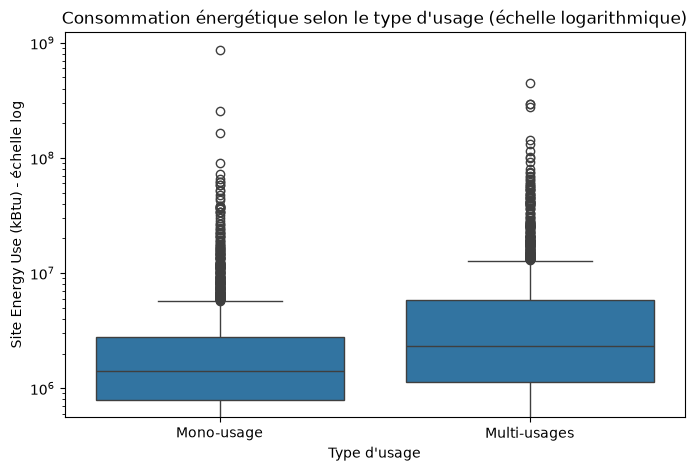

In [ ]:
# Visualisation de la consommation énergétique selon le type d'usage (échelle logarithmique)

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df_building_consumption,
    x="usage_type",
    y="siteenergyuse(kbtu)"
)

ax.set_yscale("log")

plt.title("Consommation énergétique selon le type d'usage (échelle logarithmique)")
plt.xlabel("Type d'usage")
plt.ylabel("Site Energy Use (kBtu) - échelle log")

plt.show()

> - Les bâtiments à usage multiple ont tendance à consommer plus d'énergie et présentent une plus grande variabilité de consommation que les bâtiments à usage unique.

##### **Description des variables principales**

In [ ]:
# Tableau récapitulatif des principales variables utilisées dans le projet

variables_summary = pd.DataFrame({
    "Variable": [
        "SiteEnergyUse(kBtu)",
        "PropertyGFATotal",
        "PrimaryPropertyType",
        "BuildingType",
        "YearBuilt",
        "NumberofFloors",
        "Neighborhood",
        "ENERGYSTARScore",
        "TotalGHGEmissions",
        "GHGEmissionsIntensity"
    ],

    "Description": [
        "Consommation énergétique totale annuelle du bâtiment",
        "Surface totale du bâtiment (Gross Floor Area)",
        "Type principal du bâtiment",
        "Classification du bâtiment (mono ou multi-usages)",
        "Année de construction",
        "Nombre d'étages",
        "Quartier où se situe le bâtiment",
        "Score de performance énergétique",
        "Émissions totales de gaz à effet de serre",
        "Intensité des émissions de gaz à effet de serre"
    ],

    "Utilisation": [
        "Variable cible",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Cible alternative",
        "Variable d'analyse"
    ]
})

# Affichage avec en-têtes centrés
variables_summary.style.set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("font-weight", "bold")
        ]
    }
]).set_properties(**{
    "text-align": "left"
})

,Variable,Description,Utilisation
0,SiteEnergyUse(kBtu),Consommation énergétique totale annuelle du bâtiment,Variable cible
1,PropertyGFATotal,Surface totale du bâtiment (Gross Floor Area),Feature
2,PrimaryPropertyType,Type principal du bâtiment,Feature
3,BuildingType,Classification du bâtiment (mono ou multi-usages),Feature
4,YearBuilt,Année de construction,Feature
5,NumberofFloors,Nombre d'étages,Feature
6,Neighborhood,Quartier où se situe le bâtiment,Feature
7,ENERGYSTARScore,Score de performance énergétique,Feature
8,TotalGHGEmissions,Émissions totales de gaz à effet de serre,Cible alternative
9,GHGEmissionsIntensity,Intensité des émissions de gaz à effet de serre,Variable d'analyse


#### **Analyse des outliers**

Les variables les plus importantes pour la modélisation sont analysées individuellement afin d'identifier d'éventuelles valeurs aberrantes susceptibles d'influencer les modèles.

##### **Analyse des outliers - SiteEnergyUse(kBtu)**

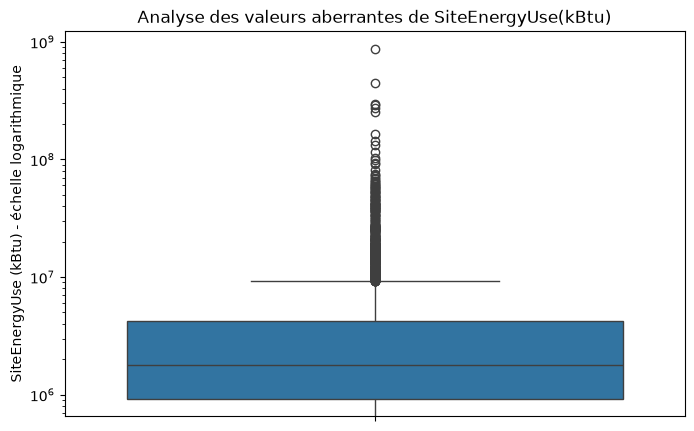

In [ ]:
# Analyse des valeurs aberrantes - SiteEnergyUse(kBtu)

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_building_consumption,
    y="siteenergyuse(kbtu)"
)

# Échelle logarithmique pour améliorer la lisibilité
ax.set_yscale("log")

plt.title("Analyse des valeurs aberrantes de SiteEnergyUse(kBtu)")
plt.ylabel("SiteEnergyUse (kBtu) - échelle logarithmique")

plt.show()


> - Le boxplot met en évidence la présence de nombreux **outliers** pour la variable **SiteEnergyUse(kBtu)**.
> - L'échelle logarithmique améliore la visualisation de la distribution tout en conservant les valeurs extrêmes.
> - Ces observations seront analysées lors de la préparation des données afin de déterminer si elles doivent être conservées ou traitées.

##### **Analyse des outliers - PropertyGFATotal**

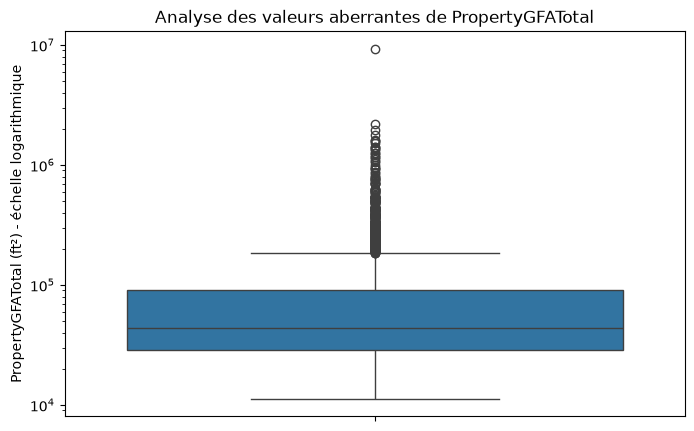

In [ ]:
# Analyse des valeurs aberrantes - PropertyGFATotal

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_building_consumption,
    y="propertygfatotal"
)

# Échelle logarithmique pour améliorer la lisibilité
ax.set_yscale("log")

plt.title("Analyse des valeurs aberrantes de PropertyGFATotal")
plt.ylabel("PropertyGFATotal (ft²) - échelle logarithmique")

plt.show()


> - Le boxplot met en évidence la présence de nombreux outliers pour la variable **PropertyGFATotal**.
> - L'échelle logarithmique améliore la visualisation de la distribution tout en conservant les bâtiments de très grande superficie.
> - Ces observations seront analysées lors de la préparation des données afin de déterminer si elles doivent être conservées ou traitées.

##### **Analyse des outliers - NumberofFloors**

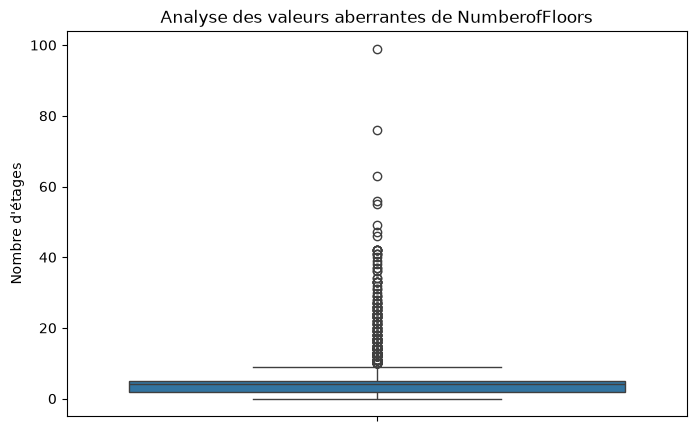

In [ ]:
# Analyse des valeurs aberrantes - NumberofFloors

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_building_consumption,
    y="numberoffloors"
)

plt.title("Analyse des valeurs aberrantes de NumberofFloors")
plt.ylabel("Nombre d'étages")

plt.show()

> - Le boxplot met en évidence la présence de plusieurs outliers pour la variable **NumberofFloors**, correspondant à des bâtiments exceptionnellement élevés.
> - La majorité des bâtiments possède un nombre d'étages relativement faible, tandis que quelques observations présentent des valeurs nettement supérieures.
> - Ces observations seront examinées lors de la préparation des données afin de vérifier leur cohérence et leur impact sur la modélisation.

##### **Analyse des outliers - TotalGHGEmissions**

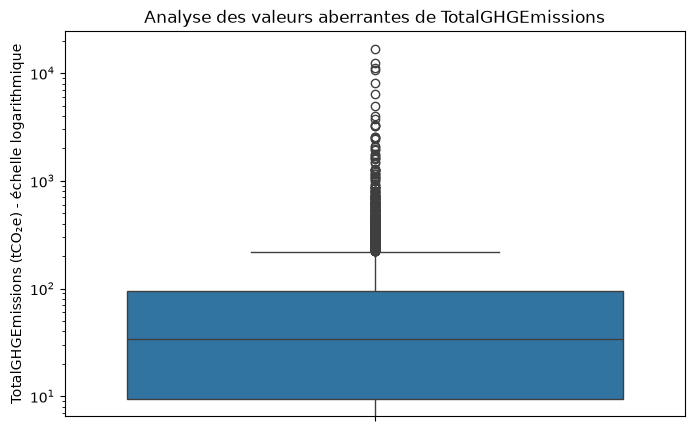

In [ ]:
# Analyse des valeurs aberrantes - TotalGHGEmissions

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_building_consumption,
    y="totalghgemissions"
)

# Échelle logarithmique pour améliorer la lisibilité
ax.set_yscale("log")

plt.title("Analyse des valeurs aberrantes de TotalGHGEmissions")
plt.ylabel("TotalGHGEmissions (tCO₂e) - échelle logarithmique")

plt.show()

> - Le boxplot met en évidence la présence de nombreux outliers pour la variable TotalGHGEmissions.
> - L'échelle logarithmique facilite la visualisation de la distribution tout en conservant les valeurs extrêmes.
> - Ces observations seront analysées lors de la préparation des données afin d'évaluer leur cohérence et leur impact sur la modélisation.

#### **Relation entre les variables**

##### **Surface du bâtiment**

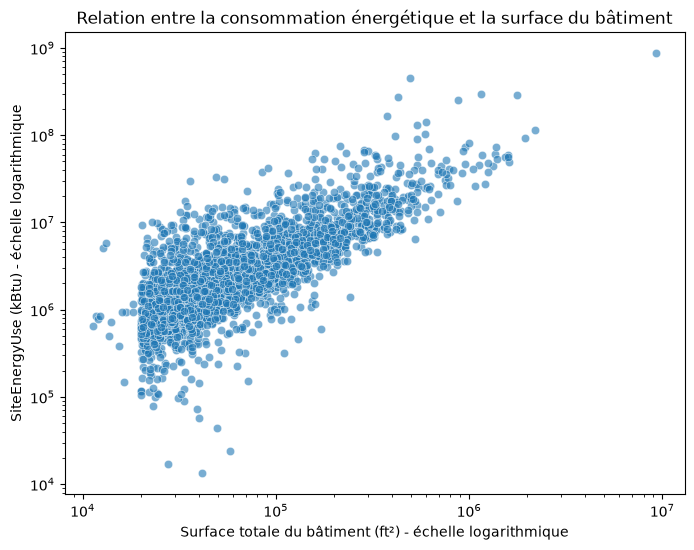

In [ ]:
# Relation entre la surface totale du bâtiment et la consommation énergétique

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_building_consumption,
    x="propertygfatotal",
    y="siteenergyuse(kbtu)",
    alpha=0.6
)

# Échelle logarithmique
plt.xscale("log")
plt.yscale("log")

plt.title("Relation entre la consommation énergétique et la surface du bâtiment")
plt.xlabel("Surface totale du bâtiment (ft²) - échelle logarithmique")
plt.ylabel("SiteEnergyUse (kBtu) - échelle logarithmique")

plt.show()

> - Une corrélation positive est observée entre la surface totale du bâtiment et la consommation énergétique.
> - Les bâtiments de plus grande superficie ont généralement une consommation énergétique plus élevée.
> - PropertyGFATotal apparaît comme l'une des variables explicatives les plus pertinentes pour la modélisation.

##### **Année de construction**

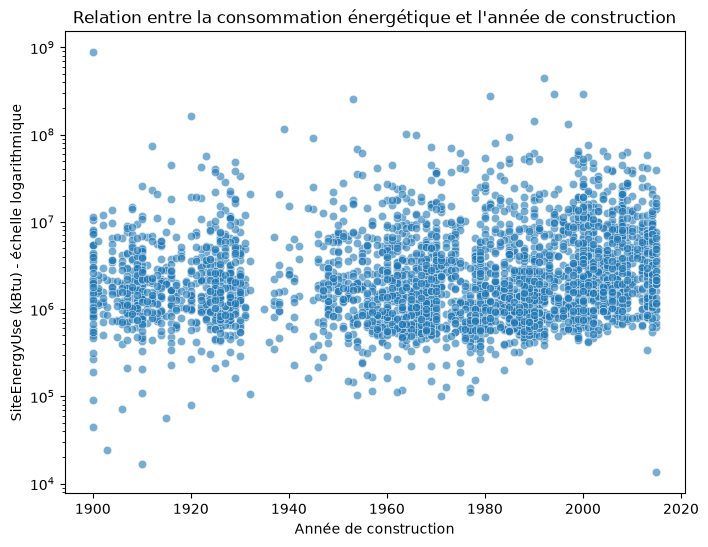

In [ ]:
# Relation entre l'année de construction et la consommation énergétique

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_building_consumption,
    x="yearbuilt",
    y="siteenergyuse(kbtu)",
    alpha=0.6
)

# Échelle logarithmique uniquement pour la consommation énergétique
plt.yscale("log")

plt.title("Relation entre la consommation énergétique et l'année de construction")
plt.xlabel("Année de construction")
plt.ylabel("SiteEnergyUse (kBtu) - échelle logarithmique")

plt.show()


> - Aucune relation linéaire forte n'est observée entre l'année de construction et la consommation énergétique.
> - Les bâtiments récents ne présentent pas systématiquement une consommation énergétique plus faible.
> - YearBuilt pourrait avoir une influence plus limitée que PropertyGFATotal sur la consommation énergétique.

##### **Type principal du bâtiment**

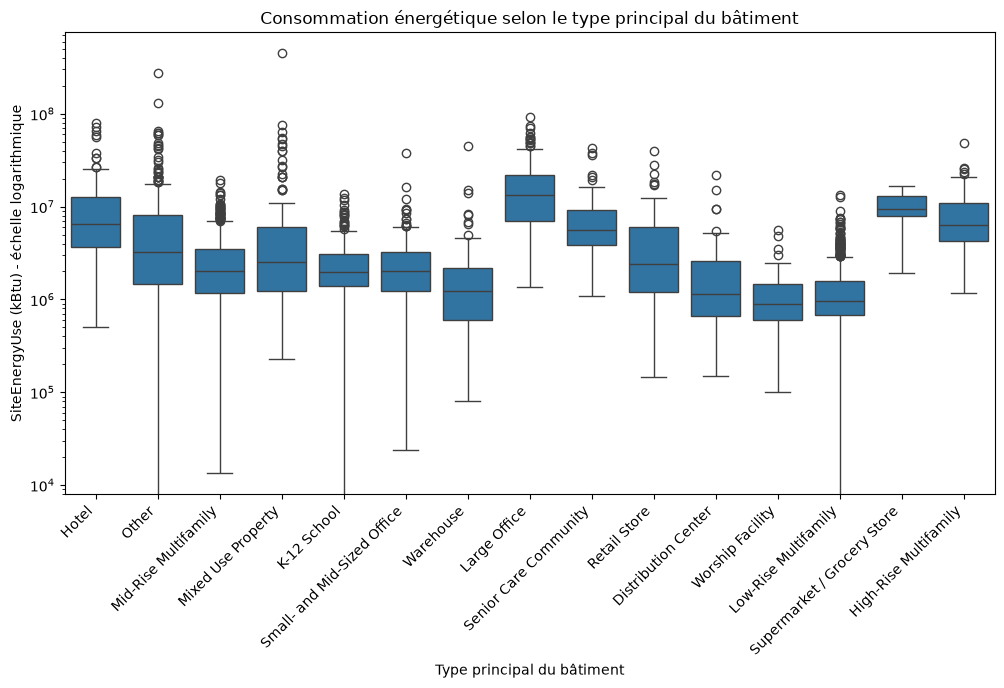

In [ ]:
# Consommation énergétique selon le type principal du bâtiment

# Sélection des 15 types de bâtiments les plus fréquents
top15 = (
    df_building_consumption["primarypropertytype"]
    .value_counts()
    .head(15)
    .index
)

df_top15 = df_building_consumption[
    df_building_consumption["primarypropertytype"].isin(top15)
]

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df_top15,
    x="primarypropertytype",
    y="siteenergyuse(kbtu)"
)

ax.set_yscale("log")

plt.xticks(rotation=45, ha="right")

plt.title("Consommation énergétique selon le type principal du bâtiment")
plt.xlabel("Type principal du bâtiment")
plt.ylabel("SiteEnergyUse (kBtu) - échelle logarithmique")

plt.show()

> - La consommation énergétique varie selon le type principal du bâtiment.
> - Les Large Office, Supermarket / Grocery Store et Hotel présentent généralement les niveaux de consommation les plus élevés.
> - Le type principal du bâtiment apparaît comme une variable explicative pertinente pour la modélisation de la consommation énergétique.

##### **Matrice de corrélation des variables numériques**

La matrice suivante permet d'identifier les variables les plus liées à la consommation énergétique

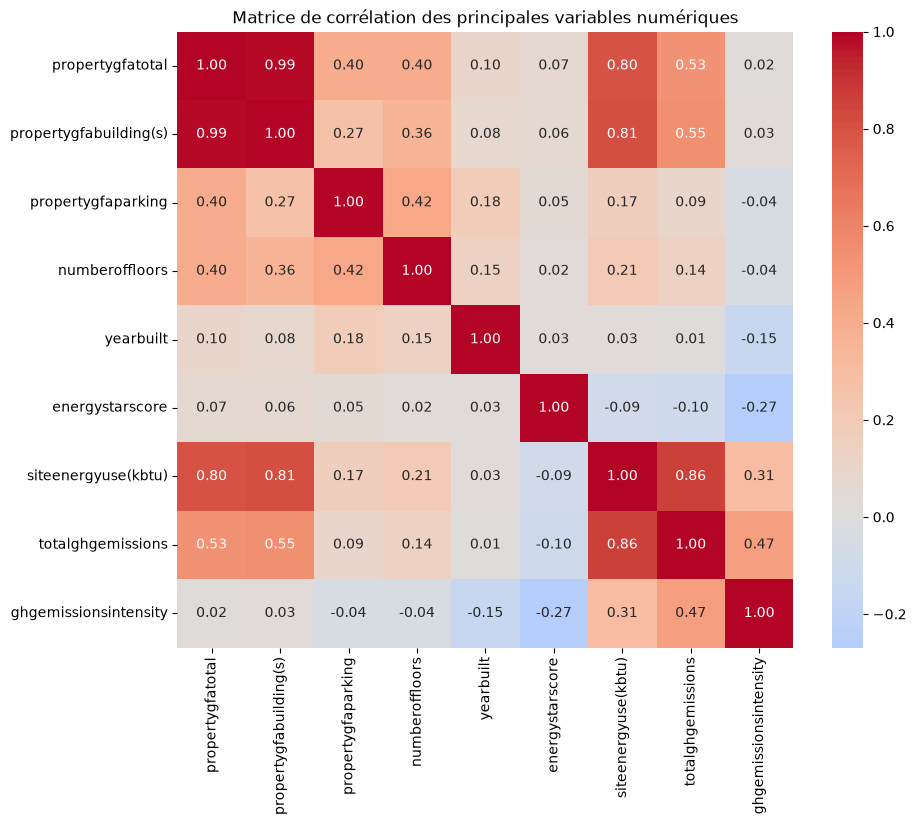

In [ ]:
# Matrice de corrélation des principales variables numériques

correlation_columns = [
    "propertygfatotal",
    "propertygfabuilding(s)",
    "propertygfaparking",
    "numberoffloors",
    "yearbuilt",
    "energystarscore",
    "siteenergyuse(kbtu)",
    "totalghgemissions",
    "ghgemissionsintensity"
]

corr = df_building_consumption[correlation_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True
)

plt.title("Matrice de corrélation des principales variables numériques")

plt.show()

> - PropertyGFATotal et PropertyGFABuilding(s) présentent une forte corrélation avec SiteEnergyUse(kBtu), confirmant l'importance de la superficie dans la consommation énergétique.
> - TotalGHGEmissions est fortement corrélée à SiteEnergyUse(kBtu), mais ne sera pas utilisée comme feature afin d'éviter toute fuite d'information (data leakage).
> - YearBuilt, NumberofFloors et ENERGYSTARScore présentent une corrélation plus faible avec la consommation énergétique.

#### **Identification des bâtiments incohérents**

Avant de préparer les données pour la modélisation, il est nécessaire d'identifier les bâtiments présentant des valeurs incohérentes.

In [ ]:
# Nombre de lignes avant vérification
print(f"Nombre de lignes avant vérification : {len(df_building_consumption)}")

# Recherche de valeurs incohérentes
incoherent_buildings = df_building_consumption[
    (df_building_consumption["propertygfatotal"] <= 0) |
    (df_building_consumption["siteenergyuse(kbtu)"] <= 0) |
    (df_building_consumption["totalghgemissions"] < 0) |
    (df_building_consumption["numberoffloors"] < 0) |
    (df_building_consumption["yearbuilt"] > 2016)
]

print(f"Nombre de bâtiments incohérents : {len(incoherent_buildings)}")

incoherent_buildings[
    [
        "osebuildingid",
        "propertygfatotal",
        "siteenergyuse(kbtu)",
        "totalghgemissions",
        "numberoffloors",
        "yearbuilt"
    ]
].head(20)

Nombre de lignes avant vérification : 3376
Nombre de bâtiments incohérents : 19


,osebuildingid,propertygfatotal,siteenergyuse(kbtu),totalghgemissions,numberoffloors,yearbuilt
28,34,126351,0.0000,0.00,1,1955
31,37,51582,0.0000,10.43,2,1989
62,87,53352,0.0000,4.19,2,1948
81,118,74468,0.0000,11.84,3,1999
85,122,58933,0.0000,16.36,2,1991
95,140,66588,0.0000,14.67,3,1991
133,217,160270,0.0000,229.38,1,1959
139,227,136188,0.0000,170.90,3,1963
152,242,52792,0.0000,0.00,2,1989
304,435,1400000,0.0000,0.00,6,1990


In [ ]:
# Suppression des bâtiments présentant des valeurs incohérentes

rows_before = len(df_building_consumption)

df_building_consumption = df_building_consumption[
    (df_building_consumption["siteenergyuse(kbtu)"] > 0) &
    (df_building_consumption["totalghgemissions"] >= 0)
].copy()

rows_after = len(df_building_consumption)

print(f"Nombre de lignes avant nettoyage : {rows_before}")
print(f"Nombre de lignes après nettoyage : {rows_after}")
print(f"Nombre de bâtiments supprimés : {rows_before - rows_after}")

Nombre de lignes avant nettoyage : 3376
Nombre de lignes après nettoyage : 3348
Nombre de bâtiments supprimés : 28


> - 19 bâtiments présentant des valeurs incohérentes ont été supprimés.
> - Les bâtiments avec une consommation énergétique égale à zéro malgré une surface renseignée, ainsi que les bâtiments avec des émissions de GES négatives, ont été considérés comme des données incohérentes et supprimés.
> - Le jeu de données nettoyé contient désormais **3357 bâtiments**, prêts pour la phase de modélisation.

#### **Conclusion**

> - La consommation énergétique est fortement liée à la superficie des bâtiments.
> - Les bâtiments multi-usages présentent généralement une consommation plus élevée.
> - Les types de bâtiments influencent significativement la consommation énergétique.
> - Plusieurs valeurs aberrantes ont été identifiées et seront prises en compte lors de la préparation des données.
> - PropertyGFATotal apparaît comme l'une des variables les plus explicatives de la variable cible.
> - 19 bâtiments présentant des valeurs incohérentes ont été supprimés.

Les observations réalisées permettront d'orienter les choix de préparation des données dans l'étape suivante.

In [ ]:
# Dimensions finales du jeu de données

print(f"Nombre de lignes : {df_building_consumption.shape[0]}")
print(f"Nombre de colonnes : {df_building_consumption.shape[1]}")

Nombre de lignes : 3348
Nombre de colonnes : 47


> - Après le nettoyage, le jeu de données contient **3348 bâtiments** et **47 colonnes**.
> - Ce jeu de données est désormais prêt pour la phase de **Feature Engineering** et de modélisation.

### **Sauvegarde du jeu de données nettoyé**

In [ ]:
from pathlib import Path

# Création du dossier
Path("../data/processed").mkdir(parents=True, exist_ok=True)

# Sauvegarde du jeu de données
df_building_consumption.to_csv(
    "../data/processed/buildings_clean.csv",
    index=False
)

print("Jeu de données sauvegardé avec succès.")
print(Path("../data/processed/buildings_clean.csv").resolve())

Jeu de données sauvegardé avec succès.
C:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\data\processed\buildings_clean.csv
